# **Import Libraries**

In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.9/107.9 kB 4.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


from sklearn.preprocessing import StandardScaler , RobustScaler , LabelEncoder , OrdinalEncoder , OneHotEncoder
import category_encoders as ce
from sklearn.model_selection import train_test_split , GridSearchCV
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


from sklearn.metrics import accuracy_score , confusion_matrix , classification_report


# **Load & Read Data**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/machine-predictive-maintenance-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'machine-predictive-maintenance-classification' dataset.
Path to dataset files: /kaggle/input/machine-predictive-maintenance-classification


In [ ]:
import os
print (os.listdir(path))

['predictive_maintenance.csv']


In [ ]:
file_path = os.path.join(path,'predictive_maintenance.csv')

df= pd.read_csv (file_path)

In [ ]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [ ]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [ ]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


# **Nulls**

In [ ]:
df.isna().sum().sum()

np.int64(0)

# **Duplicates**

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Failure Type'].value_counts()

,count
Failure Type,
No Failure,9652
Heat Dissipation Failure,112
Power Failure,95
Overstrain Failure,78
Tool Wear Failure,45
Random Failures,18


In [ ]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [ ]:
df.dtypes

,0
UDI,int64
Product ID,object
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Target,int64
Failure Type,object


# **Feature Engineering**

In [ ]:
df.drop(['UDI', 'Failure Type' , 'Product ID'] , axis =1 , inplace=True)


In [ ]:

# 1. فرق درجات الحرارة
df['Temp_Diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

# 2. القدرة الميكانيكية بالواط
df['Power_W'] = df['Torque [Nm]'] * (df['Rotational speed [rpm]'] * (2 * np.pi / 60))

# 3. معامل الإجهاد
df['Overstrain'] = df['Tool wear [min]'] * df['Torque [Nm]']

# 4. نسبة العزم إلى السرعة
df['Torque_Speed_Ratio'] = df['Torque [Nm]'] / df['Rotational speed [rpm]']


In [ ]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Temp_Diff,Power_W,Overstrain,Torque_Speed_Ratio
0,M,298.1,308.6,1551,42.8,0,0,10.5,6951.590560,0.0,0.027595
1,L,298.2,308.7,1408,46.3,3,0,10.5,6826.722724,138.9,0.032884
2,L,298.1,308.5,1498,49.4,5,0,10.4,7749.387543,247.0,0.032977
3,L,298.2,308.6,1433,39.5,7,0,10.4,5927.504659,276.5,0.027565
4,L,298.2,308.7,1408,40.0,9,0,10.5,5897.816608,360.0,0.028409


In [ ]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target',
       'Temp_Diff', 'Power_W', 'Overstrain', 'Torque_Speed_Ratio'],
      dtype='object')

# **Visualization**

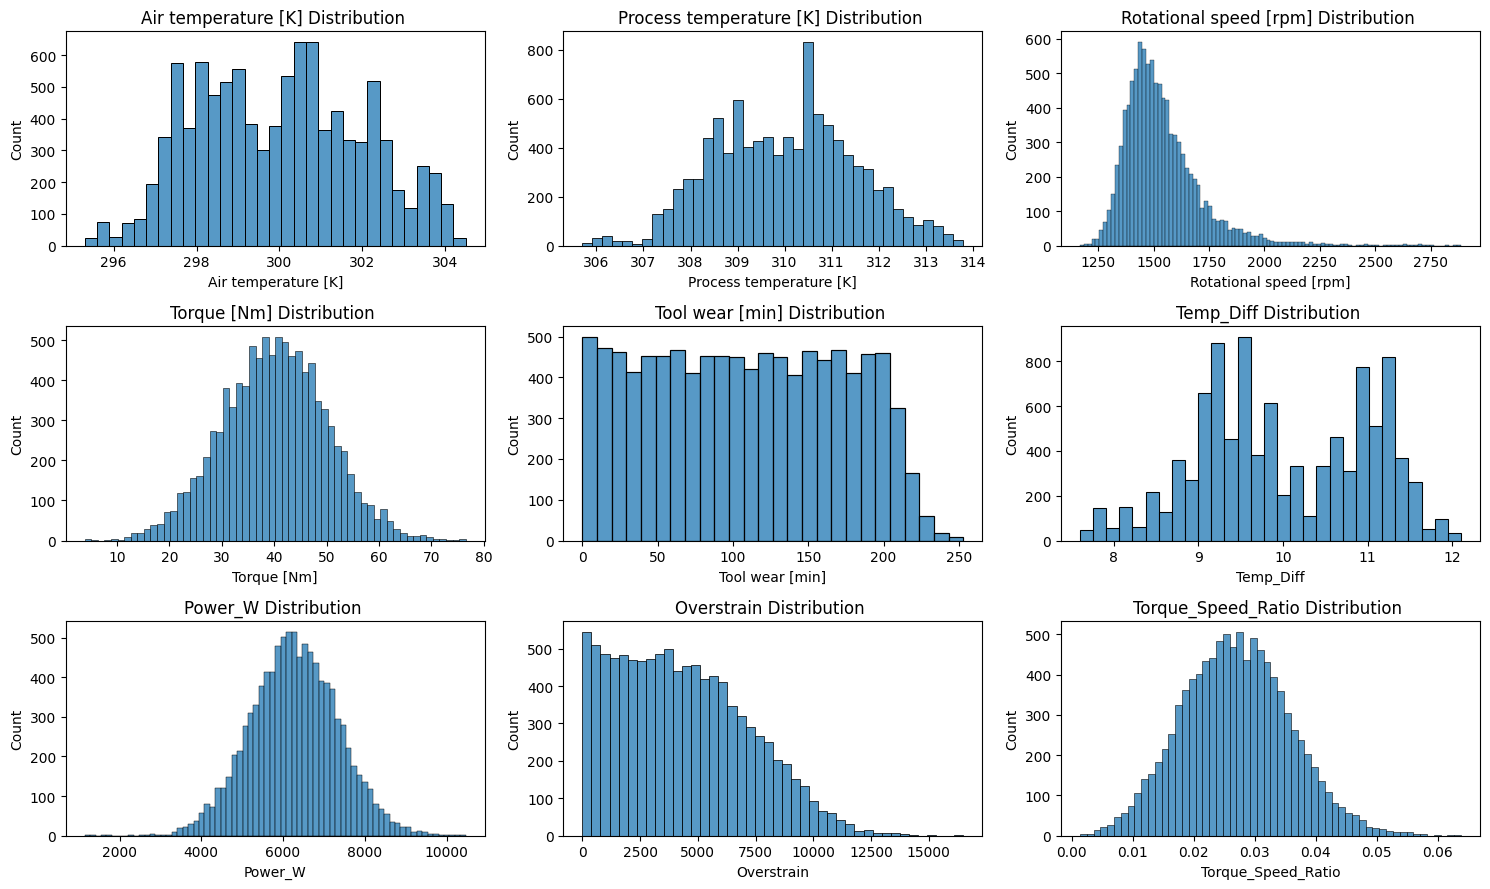

In [ ]:
cols = [ 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Temp_Diff', 'Power_W', 'Overstrain', 'Torque_Speed_Ratio']

fig , axes = plt.subplots(3, 3 , figsize=(15,9))
axes = axes.flatten()

for i , col in enumerate (cols) :
  ax=axes[i]
  sns.histplot(df[col] , ax=ax)
  ax.set_title(f"{col} Distribution ")

plt.tight_layout()
plt.show()


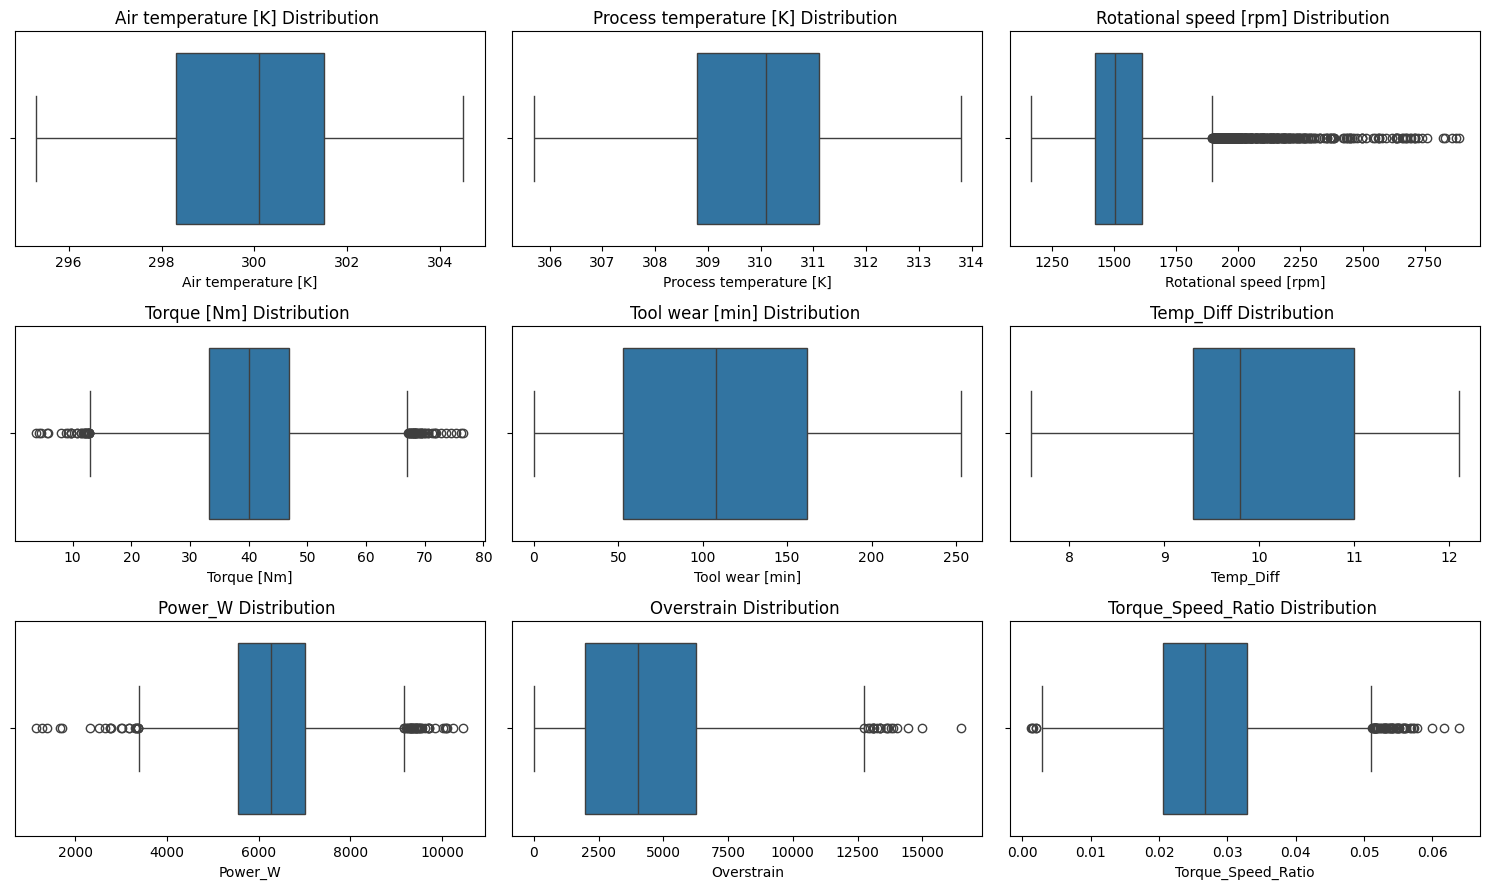

In [ ]:
cols = [ 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Temp_Diff', 'Power_W', 'Overstrain', 'Torque_Speed_Ratio']

fig , axes = plt.subplots(3, 3 , figsize=(15,9))
axes = axes.flatten()

for i , col in enumerate (cols) :
  ax=axes[i]
  sns.boxplot(x=df[col] , ax=ax)
  ax.set_title(f"{col} Distribution ")

plt.tight_layout()
plt.show()


# Numerical Features vs Target

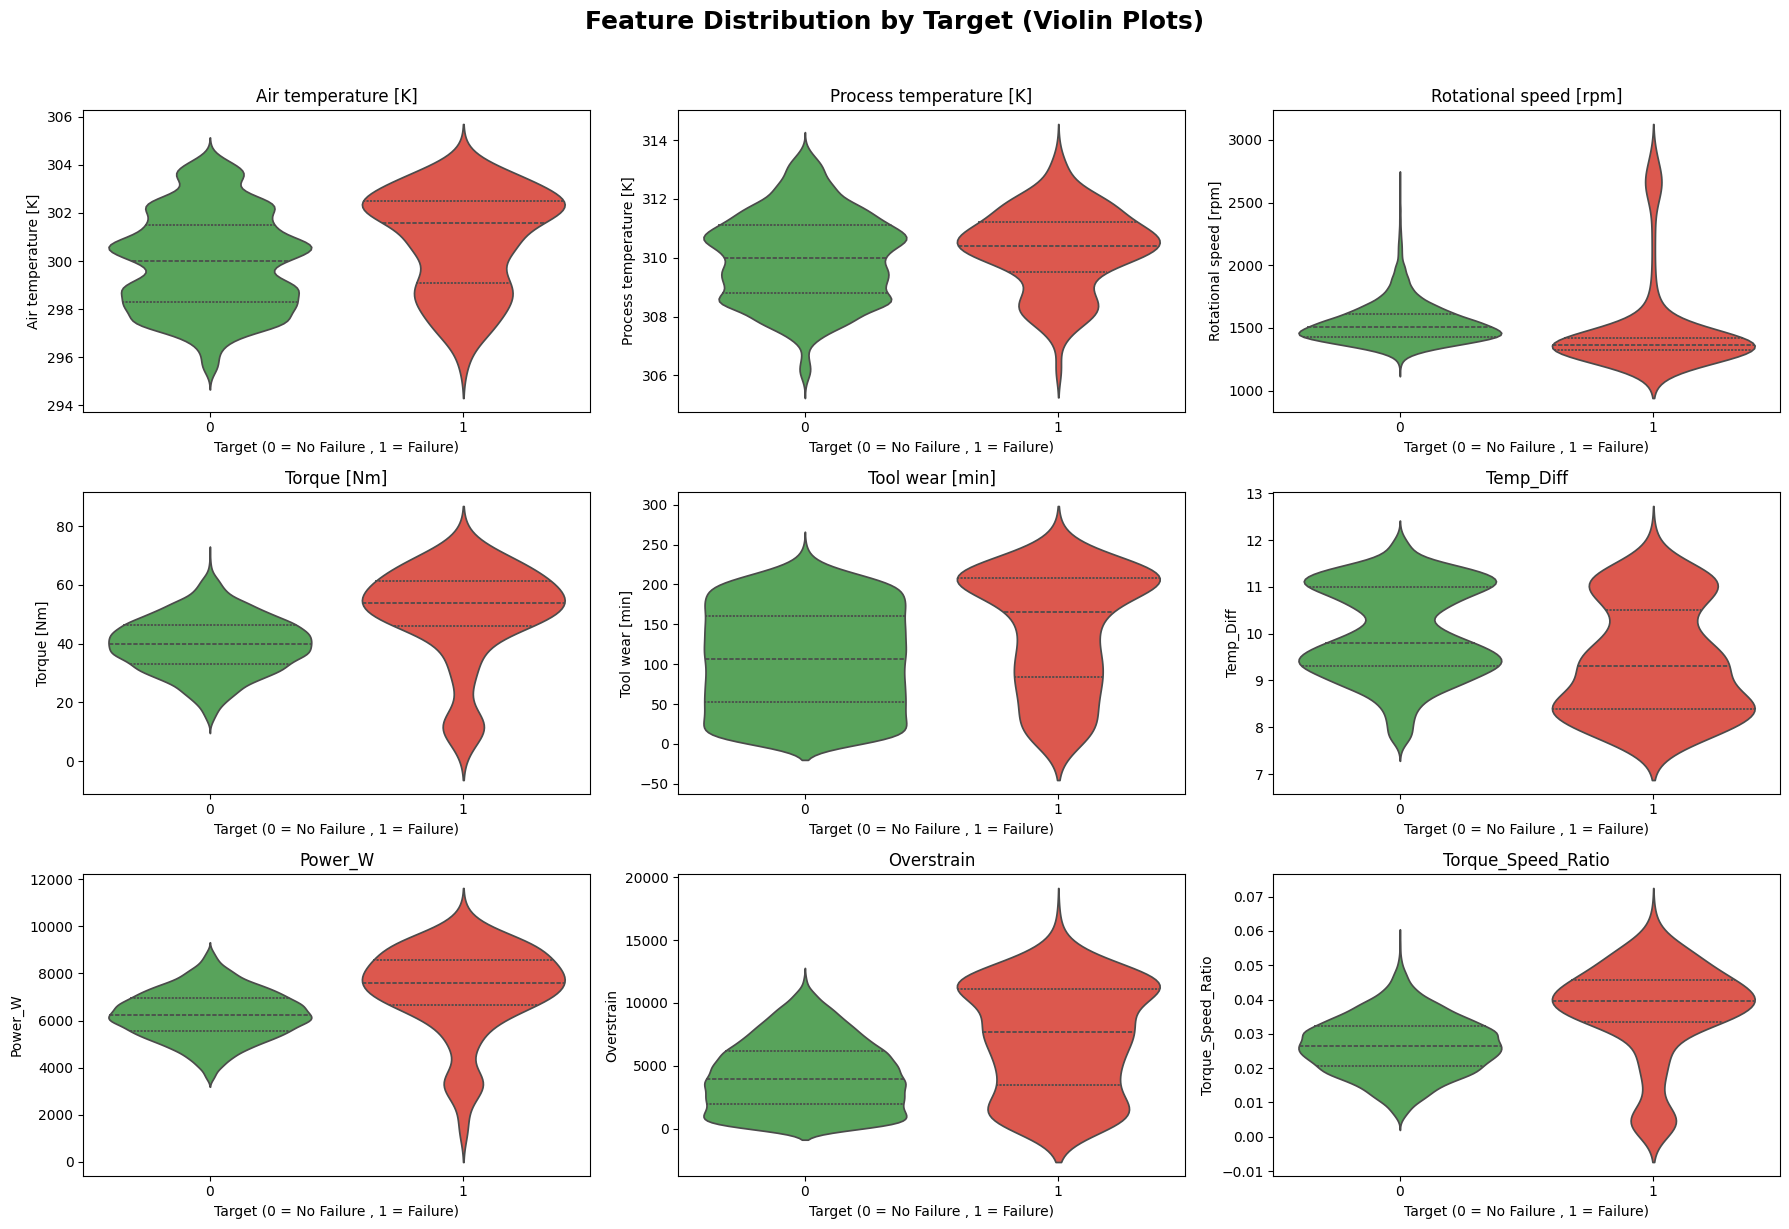

In [ ]:
failure_palette = {
    0: '#4CAF50',
    1: '#F44336'
}
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    sns.violinplot(data=df, x='Target', y=col, ax=ax,
                    palette=failure_palette, hue='Target', legend=False, inner='quartile')
    ax.set_title(col)
    ax.set_xlabel('Target (0 = No Failure , 1 = Failure)')

fig.suptitle('Feature Distribution by Target (Violin Plots)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Relations

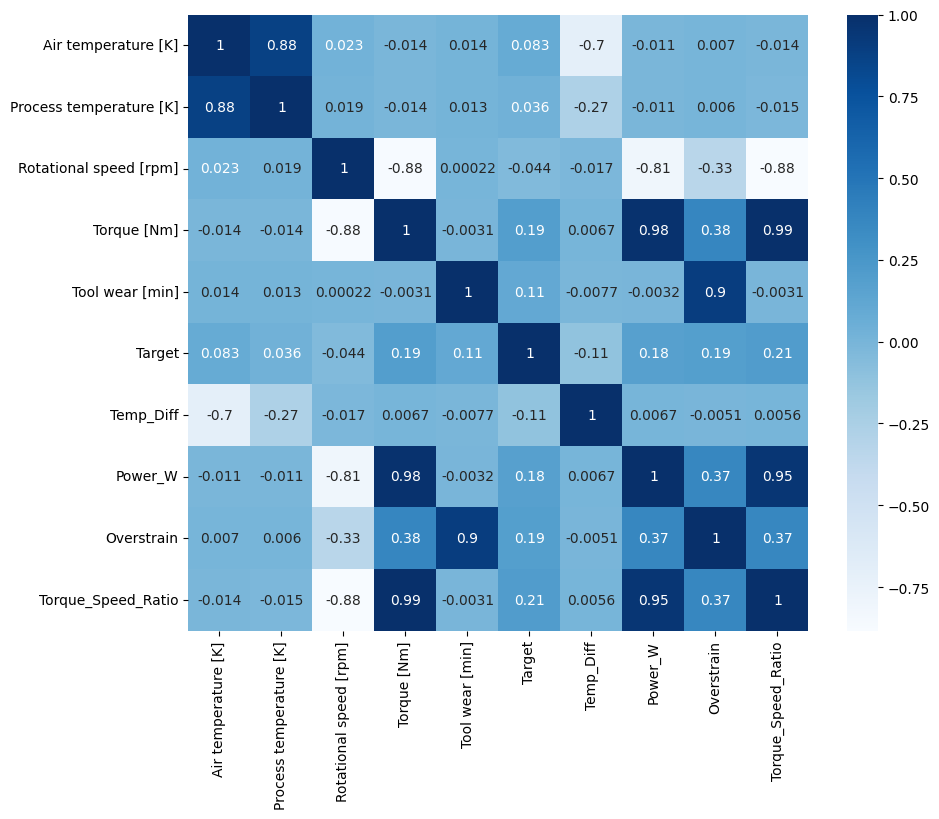

In [ ]:
num_df = df.select_dtypes(include="number")
crr = num_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(crr , cmap='Blues' , annot=True )
plt.show()

#### Type

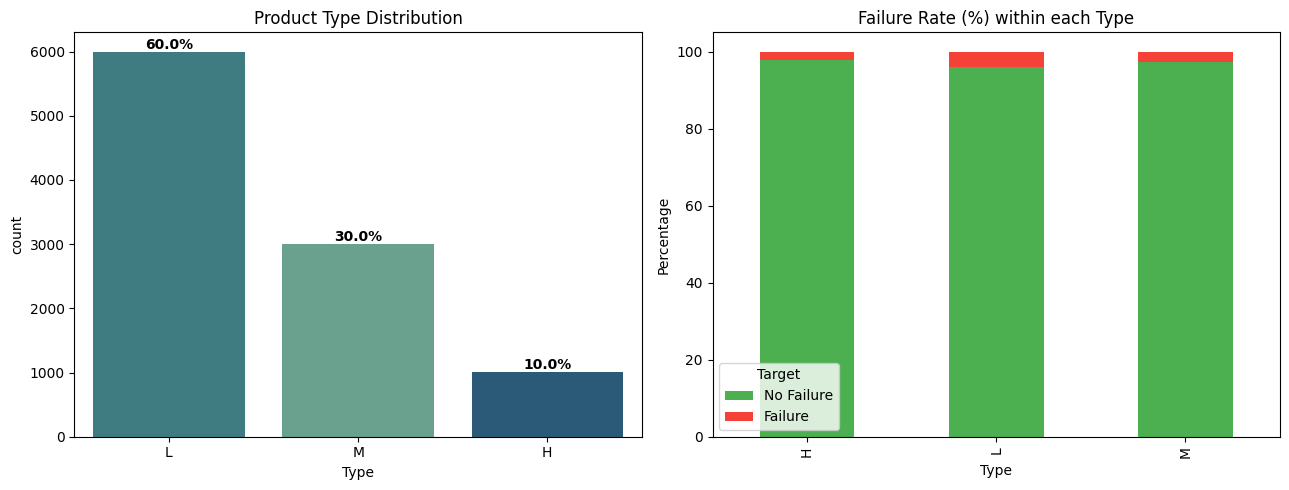

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# توزيع Type عمومًا مع نسبة كل فئة
order = df['Type'].value_counts().index
ax = sns.countplot(data=df, x='Type', order=order, ax=axes[0], palette='crest', hue='Type', legend=False)
total = len(df)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Product Type Distribution')

# نسبة العطل جوه كل نوع Type
type_target = pd.crosstab(df['Type'], df['Target'], normalize='index') * 100
type_target.plot(kind='bar', stacked=True, ax=axes[1],
                  color=[failure_palette[0], failure_palette[1]])
axes[1].set_title('Failure Rate (%) within each Type')
axes[1].set_ylabel('Percentage')
axes[1].legend(['No Failure', 'Failure'], title='Target')

plt.tight_layout()
plt.show()

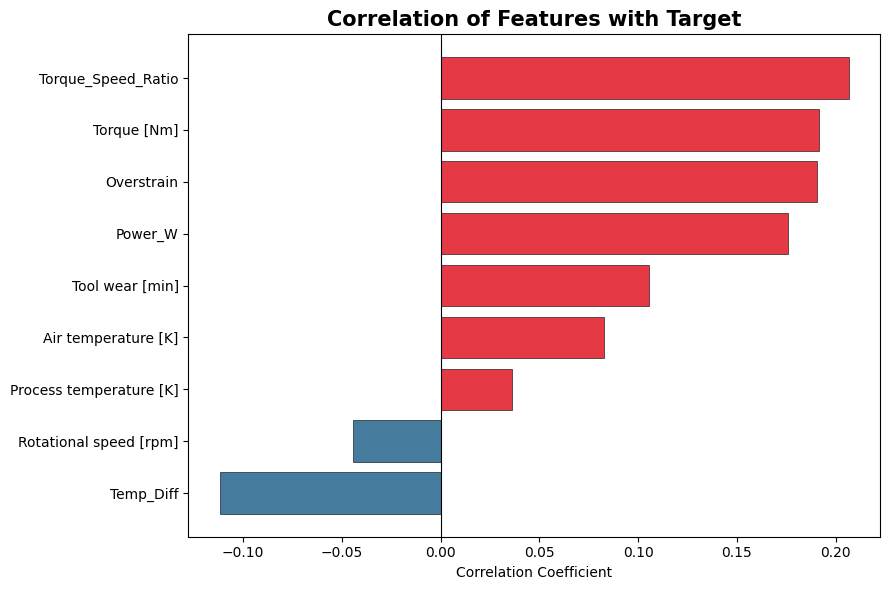

In [ ]:
target_corr = num_df.corr()['Target'].drop('Target').sort_values()

plt.figure(figsize=(9, 6))
colors = ['#E63946' if v > 0 else '#457B9D' for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black', linewidth=0.4)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Features with Target', fontsize=15, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

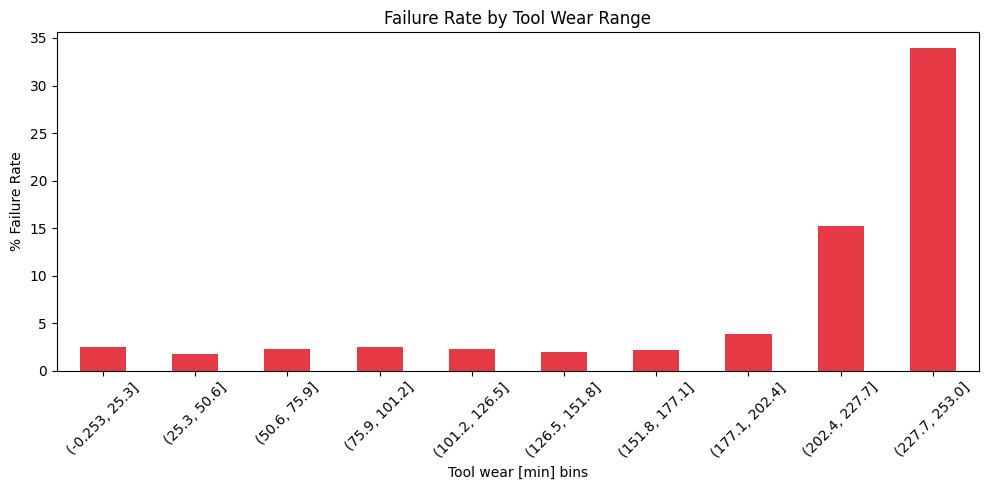

In [ ]:
df['wear_bin'] = pd.cut(df['Tool wear [min]'], bins=10)
wear_failure = df.groupby('wear_bin', observed=True)['Target'].mean() * 100

plt.figure(figsize=(10, 5))
wear_failure.plot(kind='bar', color='#E63946')
plt.title('Failure Rate by Tool Wear Range')
plt.ylabel('% Failure Rate')
plt.xlabel('Tool wear [min] bins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df.drop(columns='wear_bin', inplace=True)

#### Target Column

In [ ]:
df['Target'].value_counts(normalize=True)*100

,proportion
Target,
0,96.61
1,3.39


In [ ]:
df['Target'].value_counts()

,count
Target,
0,9661
1,339


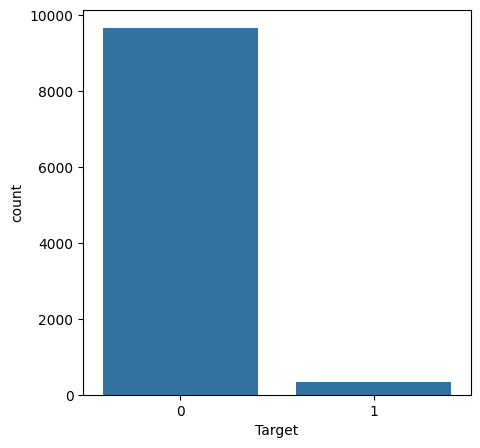

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(data = df , x='Target')
plt.show()

# **Encoding**

In [ ]:
df['Type'].unique()

array(['M', 'L', 'H'], dtype=object)

In [ ]:
en = OrdinalEncoder(categories=[['L', 'M', 'H']])
df[['Type']] = en.fit_transform(df[['Type']])

In [ ]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Temp_Diff,Power_W,Overstrain,Torque_Speed_Ratio
0,1.0,298.1,308.6,1551,42.8,0,0,10.5,6951.590560,0.0,0.027595
1,0.0,298.2,308.7,1408,46.3,3,0,10.5,6826.722724,138.9,0.032884
2,0.0,298.1,308.5,1498,49.4,5,0,10.4,7749.387543,247.0,0.032977
3,0.0,298.2,308.6,1433,39.5,7,0,10.4,5927.504659,276.5,0.027565
4,0.0,298.2,308.7,1408,40.0,9,0,10.5,5897.816608,360.0,0.028409


# **Split**

In [ ]:
X = df.drop('Target' , axis=1)
y = df['Target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)

print (f"X_train : {X_train.shape}")
print (f"y_train : {y_train.shape}")

print (f"X_test : {X_test.shape}")
print (f"y_test : {y_test.shape}")

X_train : (8000, 10)
y_train : (8000,)
X_test : (2000, 10)
y_test : (2000,)


# **Scaling**

In [ ]:
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Balancing**

In [ ]:
df['Target'].value_counts()

,count
Target,
0,9661
1,339


In [ ]:
y_train.value_counts()

,count
Target,
0,7729
1,271


In [ ]:
smote = SMOTE(sampling_strategy=0.3 , random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


print(y_train.value_counts())

Target
0    7729
1    2318
Name: count, dtype: int64


In [ ]:
y_train.value_counts()

,count
Target,
0,7729
1,2318


# **Models**

## ***For Models Combarison***

In [ ]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

# قائمة عامة لحفظ نتائج جميع الموديلات
results_list = []


def evaluate_and_record(
    model, model_name, X_train, y_train, X_test, y_test, threshold=0.5
):
    # استخدام predict_proba مع الـ threshold المختار (أو 0.5 للوجيستك بشكل افتراضي)
    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    y_train_pred = (y_train_prob >= threshold).astype(int)
    y_test_pred = (y_test_prob >= threshold).astype(int)

    # حساب وتخزين كافة المقاييس بنفس ترتيب الجدول المقارن
    results_list.append(
        {
            "Model": model_name,
            "Best Threshold": threshold,
            "Train Accuracy": accuracy_score(y_train, y_train_pred),
            "Test Accuracy": accuracy_score(y_test, y_test_pred),
            "Train Precision": precision_score(
                y_train, y_train_pred, zero_division=0
            ),
            "Test Precision": precision_score(
                y_test, y_test_pred, zero_division=0
            ),
            "Train Recall": recall_score(y_train, y_train_pred, zero_division=0),
            "Test Recall": recall_score(y_test, y_test_pred, zero_division=0),
            "Train F1 Score": f1_score(y_train, y_train_pred, zero_division=0),
            "Test F1 Score": f1_score(y_test, y_test_pred, zero_division=0),
            "Train Balanced Accuracy": balanced_accuracy_score(
                y_train, y_train_pred
            ),
            "Test Balanced Accuracy": balanced_accuracy_score(
                y_test, y_test_pred
            ),
        }
    )

# Logistic Regression

##### Model

In [ ]:
model = LogisticRegression(
    #class_weight={0:2 , 1:2},
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

In [ ]:
model.fit(X_train , y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

##### Last Evaluation

In [ ]:

print ("======================  Train   ======================")

print (f"accuracy_score : {accuracy_score(y_train, y_train_pred )}\n")

print (f"Confusion mtrix : \n {confusion_matrix(y_train , y_train_pred)}\n")

print (f"Classification Report : \n {classification_report(y_train, y_train_pred)}\n\n")


print ("\n\n======================  Test   ======================")

print (f"accuracy_score : {accuracy_score(y_test, y_test_pred )}\n")

print (f"Confusion mtrix : \n {confusion_matrix(y_test , y_test_pred)}\n")

print (f"Classification Report : \n {classification_report(y_test, y_test_pred)}\n")

======================  Train   ======================
accuracy_score : 0.87916791081915

Confusion mtrix : 
 [[7316  413]
 [ 801 1517]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.90      0.95      0.92      7729
           1       0.79      0.65      0.71      2318

    accuracy                           0.88     10047
   macro avg       0.84      0.80      0.82     10047
weighted avg       0.87      0.88      0.88     10047





======================  Test   ======================
accuracy_score : 0.942

Confusion mtrix : 
 [[1834   98]
 [  18   50]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.99      0.95      0.97      1932
           1       0.34      0.74      0.46        68

    accuracy                           0.94      2000
   macro avg       0.66      0.84      0.72      2000
weighted avg       0.97      0.94      0.95      2000




##### For Comparison

In [ ]:
evaluate_and_record(
    model,
    "Logistic Regression",
    X_train,
    y_train,
    X_test,
    y_test,
    threshold=0.5,
)

##### Draw

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

weights = [1, 2, 3, 5, 8, 10, 14.7]
precisions = []
recalls = []
f1s = []

for w in weights:
    lr = LogisticRegression(class_weight={0: 1, 1: w}, C=0.5, max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)

    precisions.append(precision_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))
    f1s.append(f1_score(y_test, y_pred))

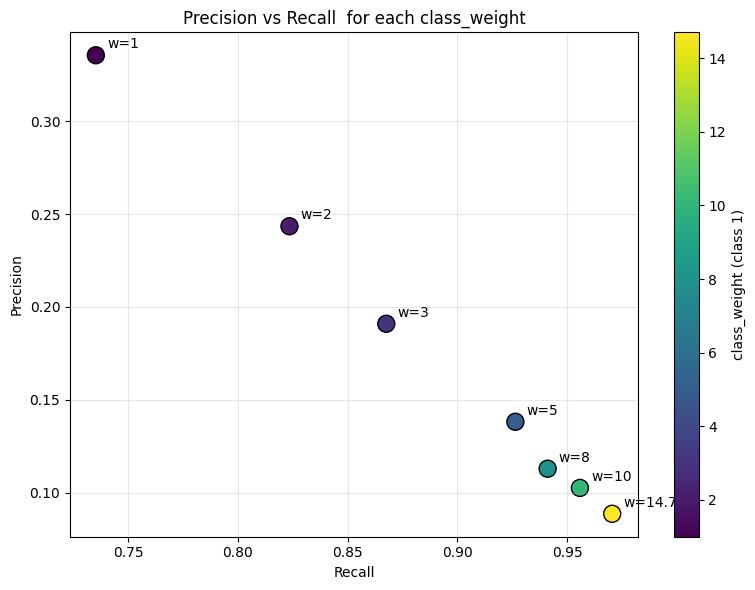

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(recalls, precisions, c=weights, cmap='viridis', s=150, edgecolors='black')

# كتابة قيمة الـ weight جنب كل نقطة
for i, w in enumerate(weights):
    plt.annotate(f'w={w}', (recalls[i], precisions[i]),
                 textcoords="offset points", xytext=(8, 5), fontsize=10)

plt.colorbar(scatter, label='class_weight (class 1)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs Recall  for each class_weight')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=======================================================================================================================================================================================================

# Decision Tree

##### Grid Seach

In [ ]:

from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(
    random_state=42
)


param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 8, 10, 12],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'min_impurity_decrease': [0, 0.001],
    'ccp_alpha': [0, 0.001]
}

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring={
        'recall': 'recall',
        'precision': 'precision',
        'f1': 'f1'
    },
    refit='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Recall:")
print(grid_search.best_score_)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best Parameters:
{'ccp_alpha': 0.001, 'criterion': 'entropy', 'max_depth': 12, 'min_impurity_decrease': 0, 'min_samples_leaf': 5, 'min_samples_split': 5}

Best CV Recall:
0.9210527295747374


##### Choosing Best Threshold



In [ ]:
y_test_prob = best_model.predict_proba(X_test)[:, 1]

for threshold in [0.7, 0.6, 0.5, 0.4, 0.3, 0.25, 0.2]:

    y_pred = (y_test_prob >= threshold).astype(int)

    print(f"\nThreshold = {threshold}")
    print(classification_report(y_test, y_pred))


Threshold = 0.7
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.63      0.78      0.70        68

    accuracy                           0.98      2000
   macro avg       0.81      0.88      0.84      2000
weighted avg       0.98      0.98      0.98      2000


Threshold = 0.6
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.52      0.85      0.65        68

    accuracy                           0.97      2000
   macro avg       0.76      0.91      0.82      2000
weighted avg       0.98      0.97      0.97      2000


Threshold = 0.5
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.52      0.85      0.64        68

    accuracy                           0.97      2000
   macro avg       0.76      0.91      0.81      2000
weighted avg       0.98

##### Last Evaluation

In [ ]:
y_train_prob = best_model.predict_proba(X_train)[:, 1]
y_test_prob = best_model.predict_proba(X_test)[:, 1]

threshold = 0.7
y_train_pred = (y_train_prob >= threshold).astype(int)
y_test_pred = (y_test_prob >= threshold).astype(int)

print ("======================  Train   ======================")

print (f"accuracy_score : {accuracy_score(y_train, y_train_pred )}\n")

print (f"Confusion mtrix : \n {confusion_matrix(y_train , y_train_pred)}\n")

print (f"Classification Report : \n {classification_report(y_train, y_train_pred)}\n")


print ("\n\n======================  Test   ======================")

print (f"accuracy_score : {accuracy_score(y_test, y_test_pred )}\n")

print (f"Confusion mtrix : \n {confusion_matrix(y_test , y_test_pred)}\n")

print (f"Classification Report : \n {classification_report(y_test, y_test_pred)}\n")

======================  Train   ======================
accuracy_score : 0.9700408082014532

Confusion mtrix : 
 [[7671   58]
 [ 243 2075]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      7729
           1       0.97      0.90      0.93      2318

    accuracy                           0.97     10047
   macro avg       0.97      0.94      0.96     10047
weighted avg       0.97      0.97      0.97     10047




======================  Test   ======================
accuracy_score : 0.977

Confusion mtrix : 
 [[1901   31]
 [  15   53]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.63      0.78      0.70        68

    accuracy                           0.98      2000
   macro avg       0.81      0.88      0.84      2000
weighted avg       0.98      0.98      0.98      2000




##### For Comparison

In [ ]:
evaluate_and_record(
    best_model,
    "Decision Tree",
    X_train,
    y_train,
    X_test,
    y_test,
    threshold = threshold
)

=================================================================================================================================================================================================

# Random Forest

##### Grid Search

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8, 10],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt'],
    'class_weight': ['balanced','balanced_subsample']
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring={
        'recall': 'recall',
        'precision': 'precision',
        'f1': 'f1'
    },
    refit='recall',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print(f"\nBest F1-score for cross-validation: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters:
{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 200}

Best F1-score for cross-validation: 0.9560


##### Choosing Best Threshold

In [ ]:

y_test_prob = best_model.predict_proba(X_test)[:, 1]

for threshold in [0.50, 0.55, 0.60, 0.65, 0.70]:

    y_pred = (y_test_prob >= threshold).astype(int)

    print(f"\n========== Threshold = {threshold} ==========")
    print(classification_report(y_test, y_pred))


========== Threshold = 0.5 ==========
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1932
           1       0.52      0.88      0.65        68

    accuracy                           0.97      2000
   macro avg       0.76      0.93      0.82      2000
weighted avg       0.98      0.97      0.97      2000


========== Threshold = 0.55 ==========
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1932
           1       0.56      0.88      0.69        68

    accuracy                           0.97      2000
   macro avg       0.78      0.93      0.84      2000
weighted avg       0.98      0.97      0.98      2000


========== Threshold = 0.6 ==========
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1932
           1       0.62      0.87      0.72        68

    accuracy                           0.98      2000
   macro a

##### Last Evaluation

In [ ]:
y_train_prob = best_model.predict_proba(X_train)[:, 1]
y_test_prob = best_model.predict_proba(X_test)[:, 1]

threshold = 0.7
y_train_pred = (y_train_prob >= threshold).astype(int)
y_test_pred = (y_test_prob >= threshold).astype(int)

print ("======================  Train   ======================")

print (f"accuracy_score : {accuracy_score(y_train, y_train_pred )}\n")

print (f"Confusion mtrix : \n {confusion_matrix(y_train , y_train_pred)}\n")

print (f"Classification Report : \n {classification_report(y_train, y_train_pred)}\n\n")


print ("\n\n======================  Test   ======================")

print (f"accuracy_score : {accuracy_score(y_test, y_test_pred )}\n")

print (f"Confusion mtrix : \n {confusion_matrix(y_test , y_test_pred)}\n")

print (f"Classification Report : \n {classification_report(y_test, y_test_pred)}\n")

======================  Train   ======================
accuracy_score : 0.9836767194187319

Confusion mtrix : 
 [[7699   30]
 [ 134 2184]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      7729
           1       0.99      0.94      0.96      2318

    accuracy                           0.98     10047
   macro avg       0.98      0.97      0.98     10047
weighted avg       0.98      0.98      0.98     10047





======================  Test   ======================
accuracy_score : 0.9885

Confusion mtrix : 
 [[1922   10]
 [  13   55]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.85      0.81      0.83        68

    accuracy                           0.99      2000
   macro avg       0.92      0.90      0.91      2000
weighted avg       0.99      0.99      0.99      2000




##### For Comparison

In [ ]:
evaluate_and_record(
    best_model,
    "Random Forest",
    X_train,
    y_train,
    X_test,
    y_test,
    threshold=threshold
)

==========================================================================================================================================================================================================

# XG Boost

##### Grid Seach

In [ ]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight_value = neg / pos
print(f"scale_pos_weight : {scale_pos_weight_value:.2f}")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'scale_pos_weight': [1, 2, scale_pos_weight_value]
}

xgb = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring={
        'recall': 'recall',
        'precision': 'precision',
        'f1': 'f1'
    },
    refit='recall',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters")
print(grid_search.best_params_)

print(f"\nأفضل F1-score على الـ cross-validation: {grid_search.best_score_:.4f}")


best_model = grid_search.best_estimator_


scale_pos_weight : 3.33
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': np.float64(3.334339948231234), 'subsample': 0.8}

أفضل F1-score على الـ cross-validation: 0.9776


##### Choosing Best Threshold

In [ ]:
## threshold

y_test_prob = best_model.predict_proba(X_test)[:, 1]

for threshold in [0.50, 0.55, 0.60, 0.65, 0.70]:

    y_pred = (y_test_prob >= threshold).astype(int)

    print(f"\n========== Threshold = {threshold} ==========")
    print(classification_report(y_test, y_pred))


========== Threshold = 0.5 ==========
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.72      0.84      0.78        68

    accuracy                           0.98      2000
   macro avg       0.86      0.91      0.88      2000
weighted avg       0.99      0.98      0.98      2000


========== Threshold = 0.55 ==========
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.75      0.84      0.79        68

    accuracy                           0.98      2000
   macro avg       0.87      0.91      0.89      2000
weighted avg       0.99      0.98      0.99      2000


========== Threshold = 0.6 ==========
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.80      0.84      0.82        68

    accuracy                           0.99      2000
   macro a

##### Last Evaluation

In [ ]:
y_train_prob = best_model.predict_proba(X_train)[:, 1]
y_test_prob = best_model.predict_proba(X_test)[:, 1]

threshold = 0.7
y_train_pred = (y_train_prob >= threshold).astype(int)
y_test_pred = (y_test_prob >= threshold).astype(int)

print ("======================  Train   ======================")

print (f"accuracy_score : {accuracy_score(y_train, y_train_pred )}\n")

print (f"Confusion mtrix : \n {confusion_matrix(y_train , y_train_pred)}\n")

print (f"Classification Report : \n {classification_report(y_train, y_train_pred)}\n\n")


print ("\n\n======================  Test   ======================")

print (f"accuracy_score : {accuracy_score(y_test, y_test_pred )}\n")

print (f"Confusion mtrix : \n {confusion_matrix(y_test , y_test_pred)}\n")

print (f"Classification Report : \n {classification_report(y_test, y_test_pred)}\n")

======================  Train   ======================
accuracy_score : 0.9994028068080024

Confusion mtrix : 
 [[7726    3]
 [   3 2315]]

Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      7729
           1       1.00      1.00      1.00      2318

    accuracy                           1.00     10047
   macro avg       1.00      1.00      1.00     10047
weighted avg       1.00      1.00      1.00     10047





======================  Test   ======================
accuracy_score : 0.9895

Confusion mtrix : 
 [[1924    8]
 [  13   55]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.87      0.81      0.84        68

    accuracy                           0.99      2000
   macro avg       0.93      0.90      0.92      2000
weighted avg       0.99      0.99      0.99      2000




##### For Comparison

In [ ]:
evaluate_and_record(
    best_model,
    "XGBoost",
    X_train,
    y_train,
    X_test,
    y_test,
    threshold=threshold
)

# **Models Comparison**

In [ ]:
# تحويل القائمة إلى DataFrame
results_df = pd.DataFrame(results_list).set_index("Model")

# ترتيب الجدول تنازلياً حسب دقة الاختبار (أو Test F1 Score)
#results_df = results_df.sort_values(by="Test Accuracy", ascending=False)

# عرض الجدول
results_df

,Best Threshold,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score,Train Balanced Accuracy,Test Balanced Accuracy
Model,,,,,,,,,,,
Logistic Regression,0.5,0.879168,0.9420,0.786010,0.337838,0.654443,0.735294,0.714218,0.462963,0.800504,0.842285
Decision Tree,0.7,0.970041,0.9770,0.972808,0.630952,0.895168,0.779412,0.932375,0.697368,0.943832,0.881683
Random Forest,0.7,0.983677,0.9885,0.986450,0.846154,0.942192,0.808824,0.963813,0.827068,0.969155,0.901824
XGBoost,0.7,0.999403,0.9895,0.998706,0.873016,0.998706,0.808824,0.998706,0.839695,0.999159,0.902341


<Axes: xlabel='Model'>

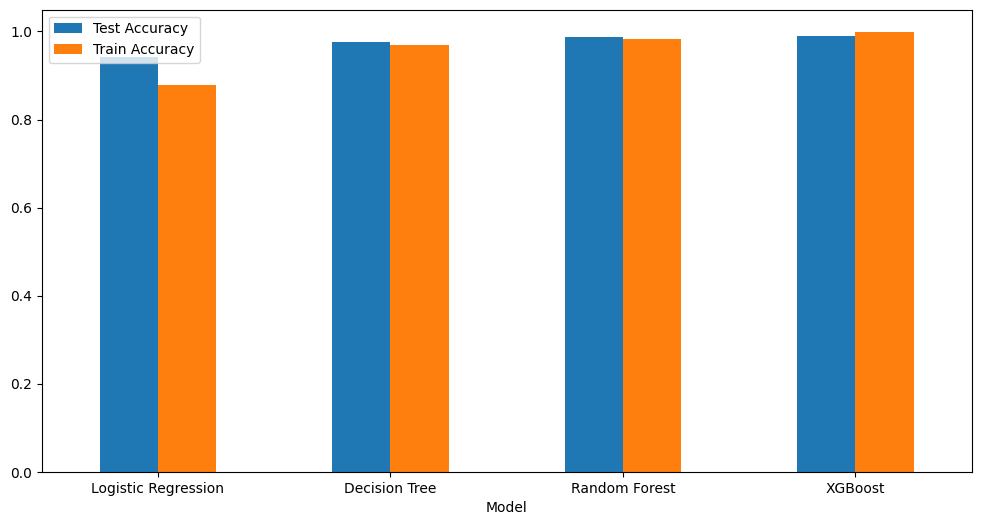

In [ ]:
results_df[["Test Accuracy", "Train Accuracy"]].plot.bar(figsize=(12, 6), rot=0)

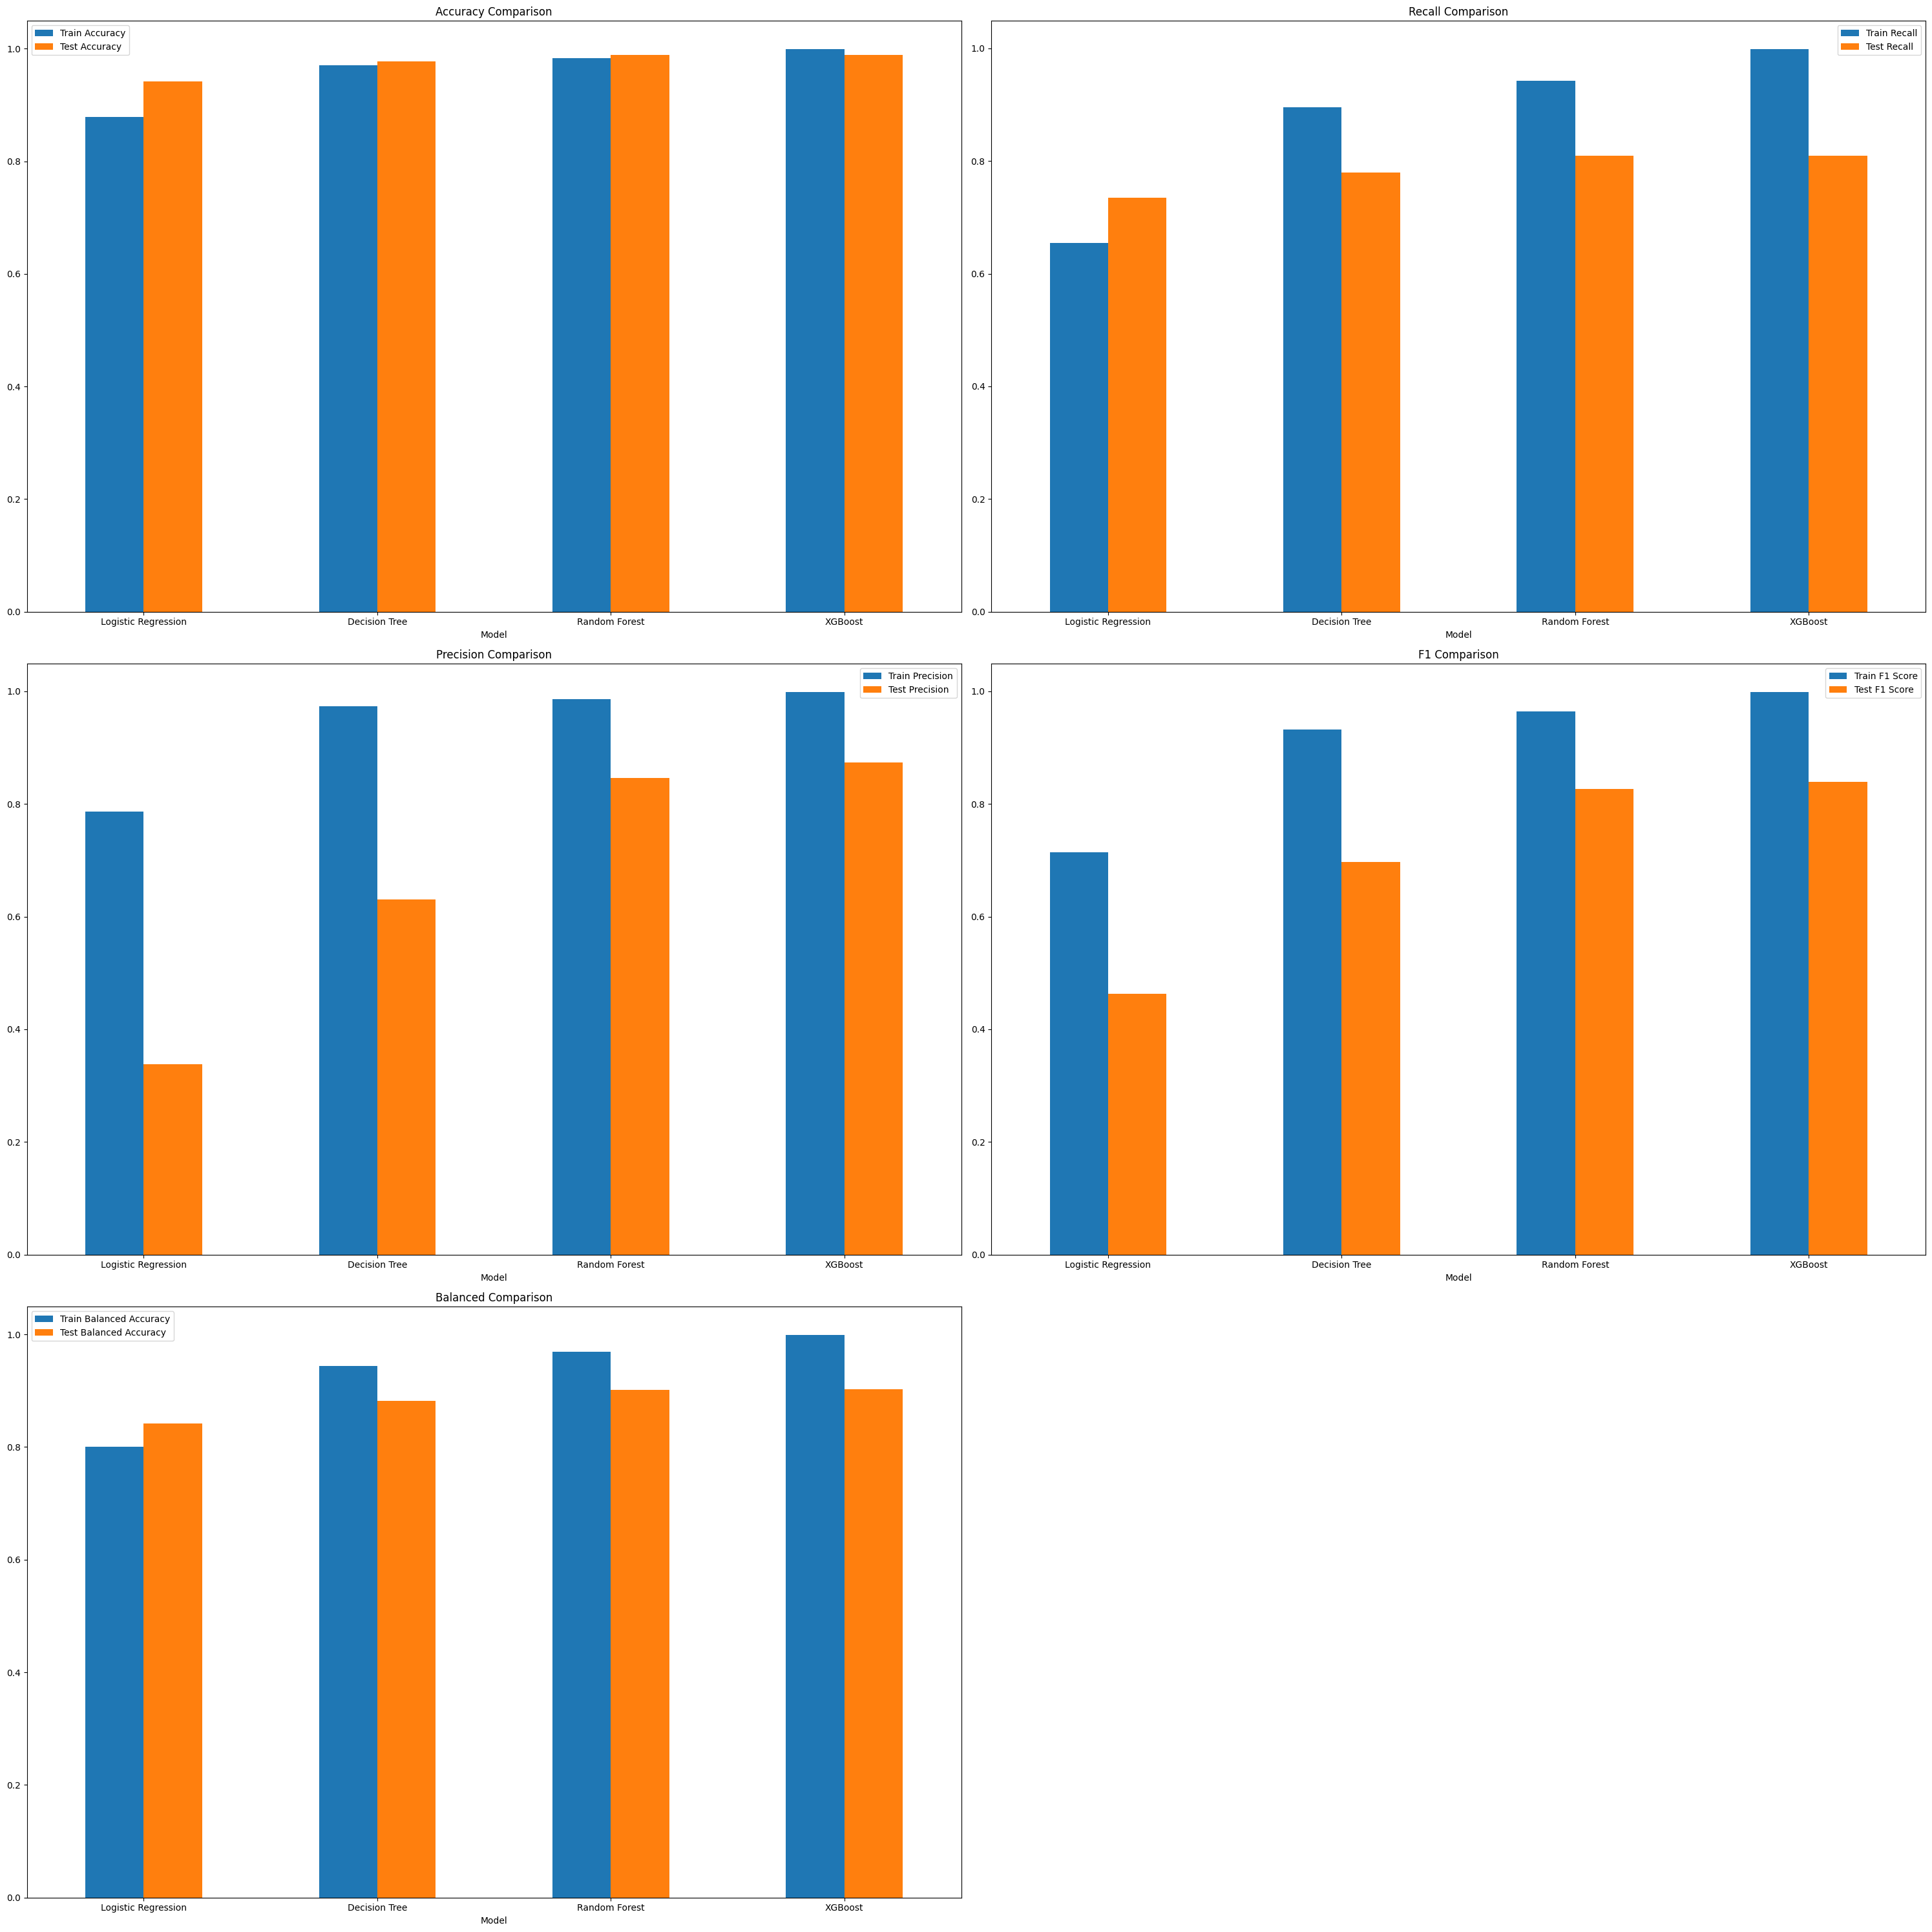

In [ ]:
cols = [
    ['Train Accuracy', 'Test Accuracy'],
    ['Train Recall', 'Test Recall'],
    ['Train Precision', 'Test Precision'],
    ['Train F1 Score', 'Test F1 Score'],
    ["Train Balanced Accuracy", "Test Balanced Accuracy"]
]

plt.figure(figsize=(30,30))

for i, col in enumerate(cols):
    ax = plt.subplot(3, 2, i+1)
    results_df[col].plot.bar(ax=ax , rot=0)
    ax.set_title(col[0].split(" ")[1] + ' Comparison')

plt.tight_layout()
plt.show()